# MDP Solving

## Learning Objectives

By the end of this notebook, you will be able to:
- explain what it means to *solve* a small Markov Decision Process
- evaluate a fixed policy using repeated Bellman updates
- improve a policy by choosing better actions from state values
- run policy iteration on a tiny grid world

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 3, lesson 04 "Markov Decision Processes (MDPs) and Value Iteration" — that lesson handed you the transition table and solved it in one pass; here you split the loop into its two halves, policy *evaluation* and policy *improvement*, and alternate them. Run `01_mdp_example.ipynb` first.

## Why this notebook matters

In the previous notebook, you defined an MDP. In this notebook, you take the next step:

1. start with a policy
2. estimate how good that policy is
3. improve it
4. repeat until the policy stops changing

That process is the bridge between *understanding an MDP* and *computing a solution*.


## Lesson Brief

This lesson moves from **describing** an MDP to **solving** it.

Students will see how policy evaluation and policy improvement turn an MDP from a problem description into a decision procedure.

Why this matters: this is the first time the class sees how RL-style reasoning can produce better behavior from the same environment.

This lesson builds directly on the MDP structure from the previous notebook.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: AlphaGo Zero is this loop, run 4.9 million times

The two-step loop this notebook implements — *evaluate the policy you have, then improve it, then
repeat* — is not a toy pattern. It is the exact skeleton of AlphaGo Zero (Silver et al., "Mastering
the game of Go without human knowledge", *Nature* **550**, 2017), and the paper says so: the
self-play algorithm "can be understood as an approximate policy iteration scheme".

Map it onto what you are about to run:

| This notebook | AlphaGo Zero |
|---|---|
| **Policy evaluation** — sweep the grid until `V` stops moving | play self-play games with the current network and record who won; the win/loss outcomes are the value samples |
| **Policy improvement** — take the best action in each state given `V` | run Monte Carlo tree search on top of the network; the search picks better moves than the raw network does, and the network is retrained to copy the search |
| **Repeat until the policy stops changing** | repeat — 4.9 million self-play games in its three-day run |

The result: starting from random weights and the rules of Go only, AlphaGo Zero beat the version of
AlphaGo that had defeated Lee Sedol **100 games to 0**.

**What goes wrong without this.** Evaluation alone gives you a report card and no improvement.
Improvement alone gives you a policy that keeps changing on the basis of values that were never
correct for it. The reason the two steps alternate is that each one is only trustworthy *after* the
other has finished. In Part 1 below you will watch a deliberately bad policy get an honest, brutal
score; only then does Part 2 have anything reliable to improve on.


## Recommended YouTube Video

To reinforce this lesson, watch **Steve Brunton - "Model Based Reinforcement Learning: Policy Iteration, Value Iteration, and Dynamic Programming"**:
[Watch on YouTube](https://www.youtube.com/watch?v=sJIFUTITfBc)

Why this pick:
- strong lecture pacing.
- Explains policy evaluation, policy improvement, and dynamic programming in one flow.
- Good match for the step from defining an MDP to actually solving it.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Value function: how good a state is under some policy.
- Policy evaluation: measuring how good a fixed policy is.
- Policy improvement: changing the policy after evaluation to choose better actions.
- Bellman update: a value update that combines immediate reward with discounted future value.
- Discount factor `gamma`: how much future rewards still matter.

### Quick Check
- Can you explain why a policy and a value function are not the same object?
- Why do we evaluate a policy before improving it?
- Why might the best action depend on future reward, not only the next reward?
- What job does `gamma` do in the update rule?

### Common Mistakes
- Thinking value means immediate reward only.
- Thinking policy evaluation already changes the policy.
- Thinking policy improvement works without using values.
- Forgetting that `gamma` controls how far ahead the agent cares to look.


## What does “solving an MDP” mean?

For a small MDP, solving means answering two questions:

- **How good is each state?**
  This is the value function.
- **What action should the agent take in each state?**
  This is the policy.

In this notebook, we will use a tiny deterministic grid world so every update is easy to follow.

Note: states and actions are encoded with small numbers here for computation. That is only a representation change from the earlier notebook, not a change in the underlying RL idea.

## Teaching flow

- First: build the environment
- Then: evaluate one fixed policy
- Then: improve the policy
- Finally: run full policy iteration

## Bellman Thinking in Plain Language

This notebook introduces a very important RL habit of thought:

> The value of a state is not only about what happens **now**, but also about what that state leads to **next**.

That is the core intuition behind Bellman updates.

### Policy evaluation

When we evaluate a policy, we ask:

`If the agent keeps following this exact policy, how good is each state?`

So policy evaluation does **not** search for a better action yet.
It only measures the quality of the current decision rule.

### Policy improvement

After we have values, we ask a new question:

`If I know which states are better, should I change the action choice somewhere?`

That is policy improvement.

So the logic is:

1. Evaluate the current policy.
2. Use those values to look for better actions.
3. Update the policy.
4. Repeat.

### Why do we need `gamma`?

`gamma` is the discount factor.
It controls how much future rewards count compared with immediate rewards.

- If `gamma` is small, the agent becomes more short-sighted.
- If `gamma` is large, the agent cares more about long-term consequences.

In this notebook, `gamma = 0.90`, which means future value matters a lot, but not as much as the present step.

### Classroom intuition

If one action gives a small reward now but leads to the goal soon, it may still be better than an action that looks safe in the next step only.
That is why solving an MDP is different from greedily chasing immediate reward.

## Checkpoint Before Coding

Before you run the code, make sure you can answer these questions:

1. What is a **policy**?
2. What is the difference between a **value function** and a **policy**?
3. Why can the best action depend on the *future* reward, not just the immediate reward?

If any of these are unclear, go back to `01_mdp_example.ipynb` before continuing.


### Step Guide

**What this cell does:** Imports NumPy/Matplotlib and prints the lesson banner—sets up printing style for small value tables.

**How to read it (weak Python OK):** Confirm the cell runs with no red error. You do not need `np.set_printoptions` on day one.

**What to expect in the output:** A title line and tidy number formatting later in the notebook.

**If you feel lost:** This cell is only “turn on the calculator display.” The ideas start in the next cell.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.set_printoptions(precision=2, suppress=True)

# Show text or numbers in the cell output area under the code.
print("=" * 70)
# Show text or numbers in the cell output area under the code.
print("MDP Solving with Policy Evaluation and Policy Iteration")
# Show text or numbers in the cell output area under the code.
print("=" * 70)

# Small 3x3 grid world used only for teaching the algorithmic steps clearly.
# Set grid height and width in cells (3x3 in this toy MDP).
N_ROWS, N_COLS = 3, 3
# Total number of states = rows * columns (flattened indices 0..N-1).
N_STATES = N_ROWS * N_COLS
# Create the list of action names (their indices are the numeric action ids).
ACTIONS = ["up", "right", "down", "left"]
# Save a value in a name so the next lines can read it.
ACTION_TO_DELTA = {
    # Dictionary/map entry: this key maps to the tuple/value on the right.
    0: (-1, 0),
    # Dictionary/map entry: this key maps to the tuple/value on the right.
    1: (0, 1),
    # Dictionary/map entry: this key maps to the tuple/value on the right.
    2: (1, 0),
    # Dictionary/map entry: this key maps to the tuple/value on the right.
    3: (0, -1),
# Part of a dict/set literal layout (syntax grouping).
}
# Map each action id to a Unicode arrow symbol for policy printing/plotting.
ACTION_TO_ARROW = {0: "↑", 1: "→", 2: "↓", 3: "←"}

# Pick which flat state ids are special terminals for rewards in transition().
GOAL_STATE = 8
# Pick which flat state ids are special terminals for rewards in transition().
PIT_STATE = 6
# Build the set of terminal state ids (used to skip Bellman backups).
TERMINAL_STATES = {GOAL_STATE, PIT_STATE}
# Set discount factor gamma used inside r + gamma * V(s') targets.
GAMMA = 0.90


# Function `to_pos` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: state.
def to_pos(state):
    # Send a value back to whoever called this function.
    return divmod(state, N_COLS)


# Function `to_state` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: row, col.
def to_state(row, col):
    # Send a value back to whoever called this function.
    return row * N_COLS + col


# Function `transition` (what it does): Deterministic transition for a tiny teaching environment.
def transition(state, action):
    """Deterministic transition for a tiny teaching environment."""
    # If the condition is True, run the indented block under this line.
    if state in TERMINAL_STATES:
        # Send a value back to whoever called this function.
        return state, 0.0

    # Save a value in a name so the next lines can read it.
    row, col = to_pos(state)
    # Another assignment—same idea: store a value for the lines below.
    d_row, d_col = ACTION_TO_DELTA[action]
    # Another assignment—same idea: store a value for the lines below.
    next_row = min(max(row + d_row, 0), N_ROWS - 1)
    # Another assignment—same idea: store a value for the lines below.
    next_col = min(max(col + d_col, 0), N_COLS - 1)
    # Unpack the one-step model output from transition(state, action).
    next_state = to_state(next_row, next_col)

    # If the condition is True, run the indented block under this line.
    if next_state == GOAL_STATE:
        # Send a value back to whoever called this function.
        return next_state, 10.0
    # If the condition is True, run the indented block under this line.
    if next_state == PIT_STATE:
        # Send a value back to whoever called this function.
        return next_state, -10.0
    # Send a value back to whoever called this function.
    return next_state, -1.0


# Function `state_grid_from_values` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: values.
def state_grid_from_values(values):
    # Create the 2D array backing the value heatmap (NaN marks unused cells).
    grid = np.full((N_ROWS, N_COLS), np.nan)
    # Start a loop: repeat the indented block once per item in the sequence.
    for state in range(N_STATES):
        # If the condition is True, run the indented block under this line.
        if state in TERMINAL_STATES:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Save a value in a name so the next lines can read it.
        r, c = to_pos(state)
        # Create the 2D array backing the value heatmap (NaN marks unused cells).
        grid[r, c] = values[state]
    # Send a value back to whoever called this function.
    return grid


# Function `plot_values_and_policy` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: values, policy, title.
# Every value in this MDP sits between -10 and +10: reaching the goal pays +10, and a state
# doomed to the pit settles at -1 + 0.9 * (-10) = -10. Pinning both value figures to that one
# range means a colour keeps the same meaning from figure to figure, so the "before" and the
# "after" pictures can honestly be compared.
VALUE_SCALE = (-10.0, 10.0)


def plot_values_and_policy(values, policy, title):
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Convert the 1D value vector into a 2D layout suitable for imshow().
    value_grid = state_grid_from_values(values)
    # Capture the AxesImage object returned by imshow (used for the colorbar).
    im = axes[0].imshow(value_grid, cmap="viridis", vmin=VALUE_SCALE[0], vmax=VALUE_SCALE[1])
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    axes[0].set_title(f"{title}: state values")
    # Same plot panel as the line above—one more small plotting tweak.
    axes[0].set_xticks(range(N_COLS))
    # Same plot panel as the line above—one more small plotting tweak.
    axes[0].set_yticks(range(N_ROWS))
    # Name the axes in words: these are grid coordinates, not anonymous indices.
    axes[0].set_xlabel("Grid column (0 = left)")
    # Same plot panel as the line above—one more small plotting tweak.
    axes[0].set_ylabel("Grid row (0 = top)")
    # Start a loop: repeat the indented block once per item in the sequence.
    for state in range(N_STATES):
        # Save a value in a name so the next lines can read it.
        r, c = to_pos(state)
        # If the condition is True, run the indented block under this line.
        if state == GOAL_STATE:
            # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
            label = "G"
        # Else-if: only checked when the earlier if/elif tests were False.
        elif state == PIT_STATE:
            # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
            label = "P"
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
            label = f"{values[state]:.1f}"
        # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
        # Dark text on the bright (high-value) cells, white text on the dark ones,
        # so every number stays readable whatever the colour underneath.
        shade = "black" if values[state] > sum(VALUE_SCALE) / 2 else "white"
        axes[0].text(c, r, label, ha="center", va="center", color=shade)
    # Change something about the whole figure (not just one small subplot).
    value_bar = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
    # Say what the colours measure.
    value_bar.set_label("Value V(s): expected discounted return")

    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_title(f"{title}: policy")
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_xlim(-0.5, N_COLS - 0.5)
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_ylim(N_ROWS - 0.5, -0.5)
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_xticks(range(N_COLS))
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_yticks(range(N_ROWS))
    # Same coordinate names as the left panel, so the two can be read side by side.
    axes[1].set_xlabel("Grid column (0 = left)")
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_ylabel("Grid row (0 = top)")
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].grid(True)
    # Start a loop: repeat the indented block once per item in the sequence.
    for state in range(N_STATES):
        # Save a value in a name so the next lines can read it.
        r, c = to_pos(state)
        # If the condition is True, run the indented block under this line.
        if state == GOAL_STATE:
            # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
            symbol = "G"
        # Else-if: only checked when the earlier if/elif tests were False.
        elif state == PIT_STATE:
            # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
            symbol = "P"
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
            symbol = ACTION_TO_ARROW[policy[state]]
        # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
        axes[1].text(c, r, symbol, ha="center", va="center", fontsize=13)
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


# Function `plot_deltas` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: deltas, title.
def plot_deltas(deltas, title):
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.figure(figsize=(5, 3))
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    # Count sweeps from 1: "sweep 1" is the first pass over the states.
    plt.plot(range(1, len(deltas) + 1), deltas, marker="o")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.title(title)
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    # Sweeps are counted, not measured: force whole-number ticks.
    plt.xticks(range(1, len(deltas) + 1))
    # Same plot panel as the line above—one more small plotting tweak.
    plt.xlabel("Sweep number")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.ylabel("Largest value change in that sweep")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.grid(True, alpha=0.3)
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


# Function `print_state_labels` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: no named parameters in the signature.
def print_state_labels():
    # Show text or numbers in the cell output area under the code.
    print("\nState layout:")
    # Start a loop: repeat the indented block once per item in the sequence.
    for r in range(N_ROWS):
        # Use a temporary list to format one printed row of the grid.
        row = []
        # Start a loop: repeat the indented block once per item in the sequence.
        for c in range(N_COLS):
            # Convert (row, col) to the flat state id used by arrays like values[s].
            s = to_state(r, c)
            # If the condition is True, run the indented block under this line.
            if s == GOAL_STATE:
                # Add one new item to the end of a list (the list grows in place).
                row.append(" G ")
            # Else-if: only checked when the earlier if/elif tests were False.
            elif s == PIT_STATE:
                # Add one new item to the end of a list (the list grows in place).
                row.append(" P ")
            # Else: run this block when none of the if/elif tests above matched.
            else:
                # Add one new item to the end of a list (the list grows in place).
                row.append(f" {s} ")
        # Show text or numbers in the cell output area under the code.
        print(" ".join(row))


# Function `print_values` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: values.
def print_values(values):
    # Show text or numbers in the cell output area under the code.
    print("\nState values:")
    # Start a loop: repeat the indented block once per item in the sequence.
    for r in range(N_ROWS):
        # Use a temporary list to format one printed row of the grid.
        row = []
        # Start a loop: repeat the indented block once per item in the sequence.
        for c in range(N_COLS):
            # Convert (row, col) to the flat state id used by arrays like values[s].
            s = to_state(r, c)
            # If the condition is True, run the indented block under this line.
            if s == GOAL_STATE:
                # Add one new item to the end of a list (the list grows in place).
                row.append("  G   ")
            # Else-if: only checked when the earlier if/elif tests were False.
            elif s == PIT_STATE:
                # Add one new item to the end of a list (the list grows in place).
                row.append("  P   ")
            # Else: run this block when none of the if/elif tests above matched.
            else:
                # Add one new item to the end of a list (the list grows in place).
                row.append(f"{values[s]:6.2f}")
        # Show text or numbers in the cell output area under the code.
        print(" ".join(row))


# Function `print_policy` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: policy.
def print_policy(policy):
    # Show text or numbers in the cell output area under the code.
    print("\nPolicy:")
    # Start a loop: repeat the indented block once per item in the sequence.
    for r in range(N_ROWS):
        # Use a temporary list to format one printed row of the grid.
        row = []
        # Start a loop: repeat the indented block once per item in the sequence.
        for c in range(N_COLS):
            # Convert (row, col) to the flat state id used by arrays like values[s].
            s = to_state(r, c)
            # If the condition is True, run the indented block under this line.
            if s == GOAL_STATE:
                # Add one new item to the end of a list (the list grows in place).
                row.append(" G ")
            # Else-if: only checked when the earlier if/elif tests were False.
            elif s == PIT_STATE:
                # Add one new item to the end of a list (the list grows in place).
                row.append(" P ")
            # Else: run this block when none of the if/elif tests above matched.
            else:
                # Add one new item to the end of a list (the list grows in place).
                row.append(f" {ACTION_TO_ARROW[policy[s]]} ")
        # Show text or numbers in the cell output area under the code.
        print(" ".join(row))


# Execute: print_state_labels()
print_state_labels()
# Show text or numbers in the cell output area under the code.
print("\nSample transition: state 0 + action 'right' ->", transition(0, 1))
# Show text or numbers in the cell output area under the code.
print("Sample transition: state 4 + action 'down'  ->", transition(4, 2))


MDP Solving with Policy Evaluation and Policy Iteration

State layout:
 0   1   2 
 3   4   5 
 P   7   G 

Sample transition: state 0 + action 'right' -> (1, -1.0)
Sample transition: state 4 + action 'down'  -> (7, -1.0)


## Part 1: Policy Evaluation

We start with a **deliberately weak** hand-written policy and ask:

> If the agent follows this policy forever, how good is each state?

This is called **policy evaluation**.

In this example:
- the agent gets `+10` for reaching the goal
- the agent gets `-10` for falling into the pit
- every normal move costs `-1`

That means a good policy should move toward the goal while avoiding the pit.

Our starting policy does **not** do that: only the right-hand column reaches the goal, while the rest of the grid drifts into the pit. Policy evaluation will expose that weakness as low state values, and Part 2 will visibly fix it.

### Step Guide

**What this cell does:** Defines a **fixed policy** (a table of actions) and `evaluate_policy`, which estimates how good that policy is in every state.

**How to read it (weak Python OK):** Think “report card for a frozen plan.” The loops fill `values[state]` until they stop changing much.

**What to expect in the output:** Arrays of numbers you can compare state by state.

**If you feel lost:** Watch `theta` and “until stable”—that only means “keep averaging future rewards until the updates get tiny.”


Fixed policy arrows:

Policy:
 ↓   ←   ↓ 
 ↓   ←   ↓ 
 P   ←   G 

State values:
-10.00 -10.00   8.00
-10.00 -10.00  10.00
  P    -10.00   G   

Number of policy-evaluation sweeps: 3
Last Bellman update size: 0.0

Checkpoint:
- States whose action chain reaches the goal get positive values.
- States whose action chain falls into the pit get strongly negative values.
- The values depend on both immediate reward and future reward.


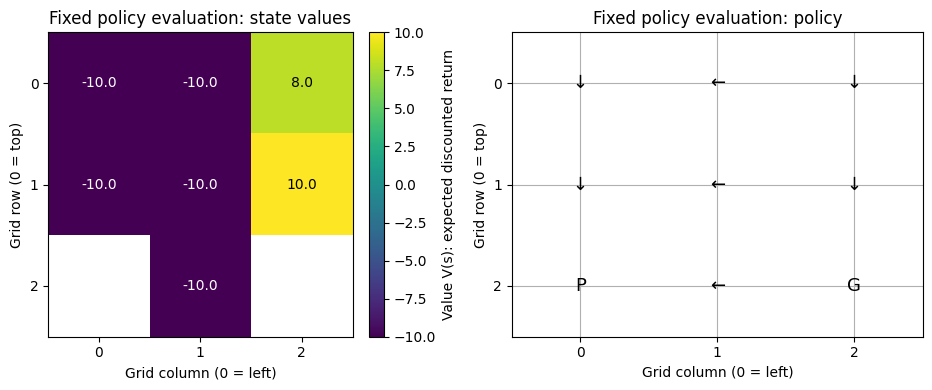

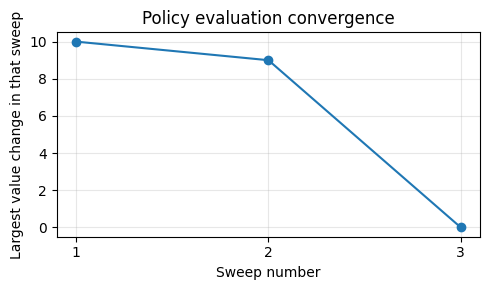

In [2]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

# A deliberately WEAK fixed policy: only the right-hand column reaches the goal;
# every other state drifts left or down, straight into the pit.
# Save a value in a name so the next lines can read it.
fixed_policy = np.array([
    # Row 0: state 0 goes down, state 1 goes left, state 2 goes down (this one is fine).
    2, 3, 2,
    # Row 1: state 3 goes down (into the pit!), state 4 goes left, state 5 goes down (reaches the goal).
    2, 3, 2,
    # Row 2: state 6 is the pit, state 7 goes left (into the pit!), state 8 is the goal.
    0, 3, 0,
])


# Function `evaluate_policy` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: policy, gamma, theta.
def evaluate_policy(policy, gamma=GAMMA, theta=1e-6):
    # Create or choose a variable used in the Bellman warm-up demo.
    values = np.zeros(N_STATES)
    # Append or initialize the per-sweep convergence trace list.
    deltas = []

    # Start a loop: repeat the indented block while the condition stays True.
    while True:
        # Track how much the value table moved during the current sweep (or max change).
        delta = 0.0
        # Start a loop: repeat the indented block once per item in the sequence.
        for state in range(N_STATES):
            # If the condition is True, run the indented block under this line.
            if state in TERMINAL_STATES:
                # Skip to the next lap of the loop (ignore the rest of this lap).
                continue
            # Evaluate the action that the current policy chooses in this state.
            # Save a value in a name so the next lines can read it.
            action = policy[state]
            # Unpack the one-step model output from transition(state, action).
            next_state, reward = transition(state, action)
            # Save a value in a name so the next lines can read it.
            new_value = reward + gamma * values[next_state]
            # Track how much the value table moved during the current sweep (or max change).
            delta = max(delta, abs(new_value - values[state]))
            # Create or choose a variable used in the Bellman warm-up demo.
            values[state] = new_value
        # Add one new item to the end of a list (the list grows in place).
        deltas.append(delta)
        # If the condition is True, run the indented block under this line.
        if delta < theta:
            # Stop the loop completely and continue after the loop block.
            break

    # Send a value back to whoever called this function.
    return values, deltas


# Create or choose a variable used in the Bellman warm-up demo.
values_fixed, deltas_fixed = evaluate_policy(fixed_policy)

# Show text or numbers in the cell output area under the code.
print("Fixed policy arrows:")
# Execute: print_policy(fixed_policy)
print_policy(fixed_policy)
# Execute: print_values(values_fixed)
print_values(values_fixed)
# Show text or numbers in the cell output area under the code.
print("\nNumber of policy-evaluation sweeps:", len(deltas_fixed))
# Show text or numbers in the cell output area under the code.
print("Last Bellman update size:", deltas_fixed[-1])

# Show text or numbers in the cell output area under the code.
print("\nCheckpoint:")
# Show text or numbers in the cell output area under the code.
print("- States whose action chain reaches the goal get positive values.")
# Show text or numbers in the cell output area under the code.
print("- States whose action chain falls into the pit get strongly negative values.")
# Show text or numbers in the cell output area under the code.
print("- The values depend on both immediate reward and future reward.")

# Save a value in a name so the next lines can read it.
plot_values_and_policy(values_fixed, fixed_policy, title="Fixed policy evaluation")
# Another assignment—same idea: store a value for the lines below.
plot_deltas(deltas_fixed, title="Policy evaluation convergence")


## Part 2: Policy Improvement and Policy Iteration

Policy evaluation tells us how good the current policy is.

Policy improvement asks a second question:

> If I know the values, which action looks best from each state?

If we repeatedly **evaluate** and then **improve**, we get **policy iteration**.

### Common misconception

A policy is **not** the same thing as the value function.

- The **policy** says what to do.
- The **value function** says how good a state is if you follow a policy.

### Step Guide

**What this cell does:** Adds `improve_policy` and **`policy_iteration`**: improve the plan, re-score it, repeat until the policy stops changing.

**How to read it (weak Python OK):** Memorize the alternation: **evaluate → improve → evaluate → improve**. Each round should feel like tightening a loose bolt.

**What to expect in the output:** Round counts and before/after policies you can compare.

**If you feel lost:** Ignore long loops at first; look only at whether the printed policy array changes between rounds.


Optimal policy after policy iteration:

Policy:
 →   →   ↓ 
 →   →   ↓ 
 P   →   G 

State values:
  4.58   6.20   8.00
  6.20   8.00  10.00
  P     10.00   G   

Policy iteration converged in 3 improvement rounds.

Reflection questions:
1. Why does the policy near the pit avoid that state?
2. Why are values close to the goal higher?
3. What changed between the fixed policy and the improved policy?

Summary:
- Policy evaluation estimates state values for one policy.
- Policy improvement chooses better actions from those values.
- Policy iteration alternates both steps until the policy stops changing.
- Next notebook: value iteration solves the same kind of problem more directly.


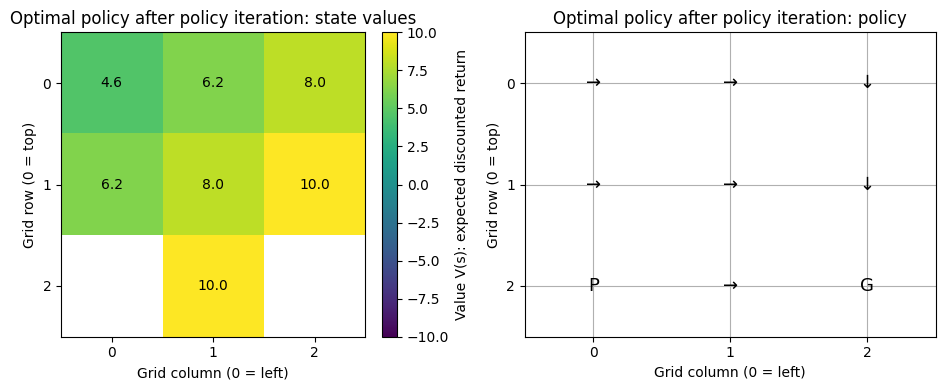

In [3]:
# Final computation: this cell usually summarizes the lesson, evaluates the result, or compares strategies.
# Pause here and ask what the numbers or tables say about the decision-making process.

# Policy iteration = evaluate -> improve -> repeat

# Function `improve_policy` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: values, gamma.
def improve_policy(values, gamma=GAMMA):
    # Create or update the greedy policy array (one int action id per state).
    policy = np.zeros(N_STATES, dtype=int)
    # Start a loop: repeat the indented block once per item in the sequence.
    for state in range(N_STATES):
        # If the condition is True, run the indented block under this line.
        if state in TERMINAL_STATES:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Create a Python list that will store one scalar target per action.
        action_returns = []
        # Start a loop: repeat the indented block once per item in the sequence.
        for action in range(len(ACTIONS)):
            # Unpack the one-step model output from transition(state, action).
            next_state, reward = transition(state, action)
            # Add one new item to the end of a list (the list grows in place).
            action_returns.append(reward + gamma * values[next_state])
        # Greedy improvement: keep the action with the largest estimated return.
        # Create or update the greedy policy array (one int action id per state).
        policy[state] = int(np.argmax(action_returns))
    # Send a value back to whoever called this function.
    return policy


# Function `policy_iteration` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: initial_policy, gamma, theta.
def policy_iteration(initial_policy=None, gamma=GAMMA, theta=1e-6):
    # If the condition is True, run the indented block under this line.
    if initial_policy is None:
        # Create or update the greedy policy array (one int action id per state).
        policy = np.zeros(N_STATES, dtype=int)
    # Else: run this block when none of the if/elif tests above matched.
    else:
        # Create or update the greedy policy array (one int action id per state).
        policy = initial_policy.copy()

    # Save a value in a name so the next lines can read it.
    rounds = 0
    # Start a loop: repeat the indented block while the condition stays True.
    while True:
        # Save a value in a name so the next lines can read it.
        rounds += 1
        # Create or choose a variable used in the Bellman warm-up demo.
        values, _ = evaluate_policy(policy, gamma=gamma, theta=theta)
        # Save a value in a name so the next lines can read it.
        improved_policy = improve_policy(values, gamma=gamma)
        # If the condition is True, run the indented block under this line.
        if np.array_equal(policy, improved_policy):
            # Send a value back to whoever called this function.
            return policy, values, rounds
        # Create or update the greedy policy array (one int action id per state).
        policy = improved_policy


# Store the planning outputs from running value_iteration / greedy extraction.
optimal_policy, optimal_values, rounds = policy_iteration(fixed_policy)

# Show text or numbers in the cell output area under the code.
print("Optimal policy after policy iteration:")
# Execute: print_policy(optimal_policy)
print_policy(optimal_policy)
# Execute: print_values(optimal_values)
print_values(optimal_values)
# Show text or numbers in the cell output area under the code.
print(f"\nPolicy iteration converged in {rounds} improvement rounds.")

# Show text or numbers in the cell output area under the code.
print("\nReflection questions:")
# Show text or numbers in the cell output area under the code.
print("1. Why does the policy near the pit avoid that state?")
# Show text or numbers in the cell output area under the code.
print("2. Why are values close to the goal higher?")
# Show text or numbers in the cell output area under the code.
print("3. What changed between the fixed policy and the improved policy?")

# Show text or numbers in the cell output area under the code.
print("\nSummary:")
# Show text or numbers in the cell output area under the code.
print("- Policy evaluation estimates state values for one policy.")
# Show text or numbers in the cell output area under the code.
print("- Policy improvement chooses better actions from those values.")
# Show text or numbers in the cell output area under the code.
print("- Policy iteration alternates both steps until the policy stops changing.")
# Show text or numbers in the cell output area under the code.
print("- Next notebook: value iteration solves the same kind of problem more directly.")

# Save a value in a name so the next lines can read it.
plot_values_and_policy(optimal_values, optimal_policy, title="Optimal policy after policy iteration")


### Step Guide

**What this cell does:** Draws the before/after comparison the whole lesson has been building towards: the state values under the hand-written policy next to the state values policy iteration ended on.

**How to read it (weak Python OK):** Both panels use **one** colour bar, so a colour on the left means exactly the same number as that colour on the right. Read the numbers printed in the tiles first, then the arrows.

**What to expect in the output:** Two 3x3 grids side by side, one shared colour bar, and a small printed table of before/after values so you can check the picture against the numbers.

**If you feel lost:** Compare tile 7 (bottom middle) in the two panels — it is the clearest case.

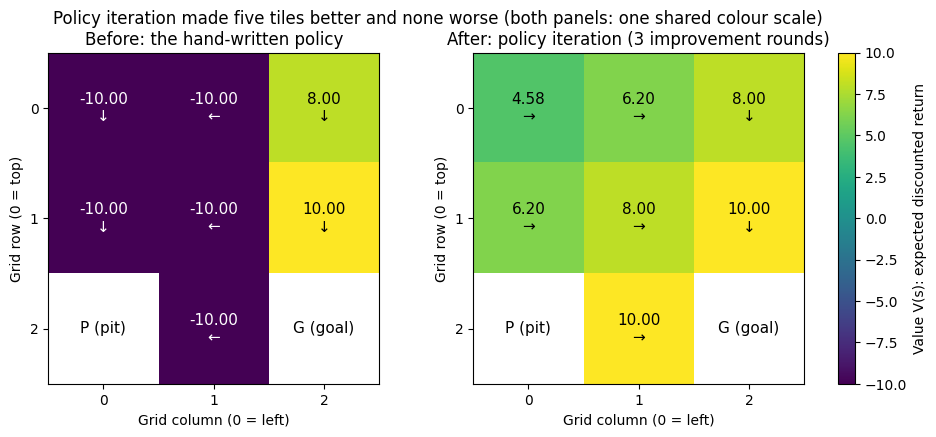

state | before | after  | change
  0   | -10.00 |   4.58 | +14.58
  1   | -10.00 |   6.20 | +16.20
  2   |   8.00 |   8.00 |  +0.00
  3   | -10.00 |   6.20 | +16.20
  4   | -10.00 |   8.00 | +18.00
  5   |  10.00 |  10.00 |  +0.00
  7   | -10.00 |  10.00 | +20.00


In [4]:
# Before/after in one picture: the same nine tiles, evaluated under the two policies.
# The point of the lesson is a COMPARISON, so both panels must be drawn on ONE colour
# scale — otherwise the same colour would stand for different numbers on the left and
# on the right, and the picture would flatter the result instead of showing it.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Reuse the helper from the setup cell: terminal tiles (P and G) are left blank.
before_grid = state_grid_from_values(values_fixed)
# The same conversion for the values policy iteration ended on.
after_grid = state_grid_from_values(optimal_values)

# One shared colour range across BOTH grids — this is the line that makes the panels comparable.
shared_low = float(np.nanmin([before_grid, after_grid]))
# The top of that shared range.
shared_high = float(np.nanmax([before_grid, after_grid]))
# The midpoint decides whether a tile's number is printed in white or in black.
shade_split = (shared_low + shared_high) / 2

# Two panels, drawn from the same recipe so nothing but the data differs.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
# Pair each panel with the values and the policy it is showing.
panels = [
    (axes[0], before_grid, fixed_policy, "Before: the hand-written policy"),
    (axes[1], after_grid, optimal_policy, f"After: policy iteration ({rounds} improvement rounds)"),
]

# Start a loop: repeat the indented block once per item in the sequence.
for ax, grid, policy, panel_title in panels:
    # vmin/vmax are fixed to the shared range, so colour means the same thing in both panels.
    image = ax.imshow(grid, cmap="viridis", vmin=shared_low, vmax=shared_high)
    # Title each panel in words.
    ax.set_title(panel_title)
    # Grid coordinates on both axes, labelled.
    ax.set_xticks(range(N_COLS))
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_yticks(range(N_ROWS))
    # Name the axes in words: these are grid coordinates, not anonymous indices.
    ax.set_xlabel("Grid column (0 = left)")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Grid row (0 = top)")
    # Write the value and the chosen action into every tile.
    for state in range(N_STATES):
        # Turn the flat state number back into a (row, column) pair.
        row, col = to_pos(state)
        # Terminal tiles carry a letter instead of a number.
        if state == GOAL_STATE:
            label, shade = "G (goal)", "black"
        # Else-if: only checked when the earlier if/elif tests were False.
        elif state == PIT_STATE:
            label, shade = "P (pit)", "black"
        # Else: an ordinary tile shows its value and the arrow the policy takes there.
        else:
            label = f"{grid[row, col]:.2f}\n{ACTION_TO_ARROW[policy[state]]}"
            # Dark text on bright tiles, white text on dark tiles.
            shade = "black" if grid[row, col] > shade_split else "white"
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(col, row, label, ha="center", va="center", color=shade, fontsize=11)

# ONE colour bar for both panels — the visual proof that the two are on the same scale.
shared_bar = fig.colorbar(image, ax=axes, fraction=0.046, pad=0.04)
# Say what the colours measure.
shared_bar.set_label("Value V(s): expected discounted return")
# A title that states the claim the figure is making.
fig.suptitle("Policy iteration made five tiles better and none worse (both panels: one shared colour scale)")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.show()

# Print the same comparison as numbers, so the figure can be checked rather than trusted.
print("state | before | after  | change")
# Start a loop: repeat the indented block once per item in the sequence.
for state in range(N_STATES):
    # Skip the two terminal tiles: they have no value to improve.
    if state in TERMINAL_STATES:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # One row per non-terminal tile.
    print(f"  {state}   | {values_fixed[state]:6.2f} | {optimal_values[state]:6.2f} | "
          f"{optimal_values[state] - values_fixed[state]:+6.2f}")


### 👁️ Read the figure

**What you are looking at.** The same nine tiles twice. Each tile prints its value `V(s)` and the arrow the policy takes there. Both panels share one colour bar, so dark purple means -10.00 on the left *and* on the right, and yellow means +10.00 on both sides. That is the only way a before/after picture can be honest.

**What to see.** On the left, five of the seven non-terminal tiles are the same dark purple: -10.00. Follow their arrows and you can see why — the hand-written policy walks left and down, into the pit column, and tile 7 points ← straight at P. On the right, after 3 improvement rounds, no tile is dark any more: the worst is 4.58 and the arrows all lead right and down towards G. Two tiles (top-right 8.00 and middle-right 10.00) have the same colour in both panels, because their actions were already the best available; the printed table under the figure confirms their change is +0.00.

**What it proves:** policy improvement never made a state worse, and it lifted five of the seven states out of the pit. That is the guarantee behind policy iteration, visible as a colour change rather than asserted in words — and it is only visible because both panels are on one scale.

## 💬 Discuss

Compare the two printed value grids. Under the weak fixed policy, five of the seven non-terminal
tiles were worth **−10.00**. After policy iteration, the same tiles are worth **4.58 to 10.00**, and
the whole thing converged in **3 improvement rounds**. Now argue:

1. Policy evaluation ran to convergence before each improvement (`Number of policy-evaluation
   sweeps: 3`). Suppose your evaluation budget is one sweep instead of three, so `V` is still wrong
   when you improve. Would you expect the loop to fail, or to be slower, or to reach a different
   answer? Which of those three would worry you most in a system running on real hardware, and why?
2. The weak policy's values were −10 almost everywhere. That is an unusually clear signal. Suppose a
   real policy scores −2.1 while an alternative scores −1.9. What would you need before you were
   willing to tell a client to switch, and what would you tell them if they asked "is 0.2 a lot?"
3. AlphaGo Zero's evaluation step was *sampled* game outcomes, not an exact sweep — it could only
   ever be approximate. Where in this notebook could you tolerate an approximate answer, and where
   would an approximation quietly break the argument?


## ⚠️ Where this breaks

**The assumption that has to hold:** you already know `P(s'|s,a)` and `R(s,a)` for every state, and
you can afford to touch every state in a sweep. Policy iteration is a *planning* algorithm. It never
interacts with anything.

- **You usually do not have the model.** Nothing in this notebook could be run on the Loon balloon
  from lesson 01, because nobody has a transition table for the stratosphere. That is the whole
  reason Units 2 and 3 exist: Monte Carlo, TD and Q-learning are what you use when the `for s in
  states` loop below is impossible to write.
- **Each evaluation is a full sweep.** Our grid has 9 states, so a sweep is free. Policy iteration's
  cost per outer round grows with the number of states, and its promise ("few outer rounds") stops
  being a bargain the moment one round no longer fits in memory or time. Unit 2, lesson 05 measures
  both sides of that trade on a real benchmark, and shows the case where the state count makes the
  whole approach impossible.
- **It gives you exactly one policy for exactly one reward.** Change the pit penalty and every number
  above is void; there is no partial credit and no transfer. Goal-conditioned RL (Unit 5, lesson 08)
  is the answer to that complaint, and it costs more.
- **Cheaper alternative:** for a small deterministic grid like this one, plain Dijkstra or A* gets
  the shortest safe path in a fraction of the time and with no discount factor to argue about. Use
  policy iteration when the transitions are *stochastic* and the trade-off between risk and reward is
  the point — which is exactly what a shortest-path algorithm cannot express.


## Closing Takeaway

**Teaching takeaway:** Once an MDP is defined, policy evaluation and policy iteration let us measure decisions and improve them step by step.

**If students remember one idea:** Solving an MDP is not magic. It is repeated reasoning about expected future reward under a policy.

**Quick check before moving on:**
- Can you explain the difference between evaluating a policy and improving a policy?
- Can you describe why repeated updates eventually reveal a better decision rule?

**Bridge to the next step:** The next lesson shows a closely related idea: value iteration, which combines evaluation and improvement in one update loop.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Heads-up (tooling preview):** this cell uses the **Gymnasium** toolkit (`gym.make`, `reset`/`step`), which is properly introduced in `04_openai_gym_setup.ipynb`. For now, just watch the motion — the API details come in lesson 04.

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.


In [5]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Bellman, R. (1957). *A Markovian Decision Process*. Journal of Mathematics and Mechanics, 6(5), 679-684.
2. Howard, R. A. (1960). *Dynamic Programming and Markov Processes*. MIT Press.
3. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 4, Dynamic Programming.
4. Schrittwieser, J., Antonoglou, I., Hubert, T. et al. (2020). *Mastering Atari, Go, Chess and Shogi by Planning with a Learned Model* (MuZero). Nature. <https://arxiv.org/abs/1911.08265>
"""))

## 📚 References

1. Bellman, R. (1957). *A Markovian Decision Process*. Journal of Mathematics and Mechanics, 6(5), 679-684.
2. Howard, R. A. (1960). *Dynamic Programming and Markov Processes*. MIT Press.
3. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 4, Dynamic Programming.
4. Schrittwieser, J., Antonoglou, I., Hubert, T. et al. (2020). *Mastering Atari, Go, Chess and Shogi by Planning with a Learned Model* (MuZero). Nature. <https://arxiv.org/abs/1911.08265>



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=11 | term=True | trunc=False


objc[74962]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x114828138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114d249c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[74962]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x114828188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114d24a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[74962]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x114827c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114d24a68). T

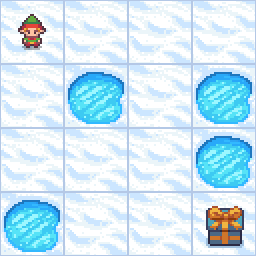

In [6]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install gymnasium pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
